# Backtesting Engine Proof of Concept

This notebook demonstrates a proof of concept for a backtesting engine with the following components:

1. **Multi-Source Data Integration** - Loading and processing market data
2. **Strategy Definition & Execution** - Creating and implementing trading strategies
3. **Realistic Trading Simulation** - Simulating trades with slippage and commissions
4. **Comprehensive Performance Analysis** - Calculating key performance metrics
5. **Professional Reporting & Visualization** - Visualizing results
6. **Modular Architecture** - Clean, modular design for extensibility

Let's implement each component step by step to build a functional proof of concept.

## Setup and Required Libraries

First, let's install and import all the necessary libraries for our backtesting engine.

In [ ]:
# Install required libraries (uncomment if needed)
# !pip install pandas numpy matplotlib scipy sqlalchemy plotly seaborn

: 

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from datetime import datetime, timedelta
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from typing import List, Dict, Tuple, Union, Optional
import warnings

# Set plot styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_theme(style="darkgrid")
warnings.filterwarnings('ignore')

# For better notebook display
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Modular Architecture Design

Let's start by designing our modular architecture. We'll create base classes for each component as described in the requirements.

In [4]:
class DataIngestion:
    """Class responsible for loading and validating market data from different sources."""
    
    def __init__(self):
        """Initialize the DataIngestion class."""
        self.data = None
        self.data_source = None
    
    def load_from_csv(self, file_path: str, date_format: str = '%Y-%m-%d') -> pd.DataFrame:
        """
        Load data from CSV file.
        
        Args:
            file_path: Path to the CSV file
            date_format: Format of the date column
            
        Returns:
            Pandas DataFrame with market data
        """
        try:
            data = pd.read_csv(file_path)
            # Convert date columns to datetime format
            if 'Date' in data.columns:
                data['Date'] = pd.to_datetime(data['Date'], format=date_format)
                data.set_index('Date', inplace=True)
            
            self.data = data
            self.data_source = f"CSV: {file_path}"
            print(f"Successfully loaded data from {file_path}")
            return data
        except Exception as e:
            print(f"Error loading data from CSV: {e}")
            return None
    
    def load_from_sql(self, connection_string: str, query: str) -> pd.DataFrame:
        """
        Load data from SQL database.
        
        Args:
            connection_string: SQL connection string
            query: SQL query to execute
            
        Returns:
            Pandas DataFrame with market data
        """
        try:
            conn = sqlite3.connect(connection_string)
            data = pd.read_sql(query, conn)
            
            # Convert date columns to datetime format
            if 'Date' in data.columns:
                data['Date'] = pd.to_datetime(data['Date'])
                data.set_index('Date', inplace=True)
            
            self.data = data
            self.data_source = f"SQL: {connection_string}"
            print(f"Successfully loaded data from SQL")
            return data
        except Exception as e:
            print(f"Error loading data from SQL: {e}")
            return None
    
    def generate_sample_data(self, start_date: str, end_date: str, ticker: str = 'SAMPLE') -> pd.DataFrame:
        """
        Generate sample price data for testing purposes.
        
        Args:
            start_date: Start date in format 'YYYY-MM-DD'
            end_date: End date in format 'YYYY-MM-DD'
            ticker: Ticker symbol for the generated data
            
        Returns:
            Pandas DataFrame with sample market data
        """
        # Parse dates
        start = pd.to_datetime(start_date)
        end = pd.to_datetime(end_date)
        
        # Generate business days
        date_range = pd.date_range(start=start, end=end, freq='B')
        
        # Generate random prices with upward trend and some volatility
        n = len(date_range)
        start_price = 100
        
        # Base trend (arithmetic Brownian motion with drift)
        trend = np.linspace(0, 30, n)  # Upward drift
        noise = np.random.normal(0, 1, n) * 2  # Daily volatility
        prices = start_price + trend + noise.cumsum()  # Cumulative noise for random walk
        
        # Ensure no negative prices
        prices = np.maximum(prices, 0.01)
        
        # Calculate OHLC from close prices with some intraday variation
        close = prices
        high = close * (1 + np.random.uniform(0, 0.015, n))
        low = close * (1 - np.random.uniform(0, 0.015, n))
        open_price = low + np.random.uniform(0, 1, n) * (high - low)
        
        # Generate volume with some correlation to price changes
        price_changes = np.diff(close, prepend=close[0])
        volume = np.abs(price_changes) * 1000000 + np.random.uniform(500000, 1500000, n)
        
        # Create DataFrame
        data = pd.DataFrame({
            'Open': open_price,
            'High': high,
            'Low': low,
            'Close': close,
            'Volume': volume.astype(int),
            'Ticker': ticker
        }, index=date_range)
        
        data.index.name = 'Date'
        self.data = data
        self.data_source = f"Generated sample data for {ticker}"
        print(f"Successfully generated sample data for {ticker}")
        return data
    
    def validate_data(self) -> bool:
        """
        Validate the loaded data to ensure quality and consistency.
        
        Returns:
            Boolean indicating if data is valid
        """
        if self.data is None:
            print("No data loaded to validate")
            return False
        
        # Check for required columns
        required_columns = ['Open', 'High', 'Low', 'Close']
        missing_columns = [col for col in required_columns if col not in self.data.columns]
        if missing_columns:
            print(f"Missing required columns: {missing_columns}")
            return False
        
        # Check for missing values
        missing_values = self.data[required_columns].isnull().sum().sum()
        if missing_values > 0:
            print(f"Warning: Found {missing_values} missing values in price data")
        
        # Check for price consistency (High ≥ Open, High ≥ Close, Low ≤ Open, Low ≤ Close)
        inconsistencies = (
            (self.data['High'] < self.data['Open']) | 
            (self.data['High'] < self.data['Close']) | 
            (self.data['Low'] > self.data['Open']) | 
            (self.data['Low'] > self.data['Close'])
        ).sum()
        
        if inconsistencies > 0:
            print(f"Warning: Found {inconsistencies} price inconsistencies")
            return False
        
        print("Data validation passed")
        return True

In [5]:
class Strategy:
    """Base class for implementing trading strategies."""
    
    def __init__(self, name: str = "BaseStrategy"):
        """Initialize the Strategy class."""
        self.name = name
        self.signals = None
    
    def generate_signals(self, data: pd.DataFrame) -> pd.DataFrame:
        """
        Generate trading signals based on the strategy logic.
        This is a base method to be overridden by specific strategy implementations.
        
        Args:
            data: Market data with OHLCV information
            
        Returns:
            DataFrame with signals (1 for buy, -1 for sell, 0 for hold)
        """
        # Default implementation: no signals
        signals = pd.DataFrame(index=data.index)
        signals['signal'] = 0
        self.signals = signals
        return signals


class MovingAverageCrossover(Strategy):
    """
    Moving Average Crossover strategy implementation.
    Generates buy signals when short MA crosses above long MA,
    and sell signals when short MA crosses below long MA.
    """
    
    def __init__(self, short_window: int = 50, long_window: int = 200):
        """
        Initialize the Moving Average Crossover strategy.
        
        Args:
            short_window: Period for short moving average
            long_window: Period for long moving average
        """
        super().__init__(name=f"MA_Cross_{short_window}_{long_window}")
        self.short_window = short_window
        self.long_window = long_window
    
    def generate_signals(self, data: pd.DataFrame) -> pd.DataFrame:
        """
        Generate trading signals for the MA Crossover strategy.
        
        Args:
            data: Market data with OHLCV information
            
        Returns:
            DataFrame with signals and moving averages
        """
        # Create copy of dataframe
        signals = pd.DataFrame(index=data.index)
        signals['price'] = data['Close']
        
        # Create moving averages
        signals[f'SMA{self.short_window}'] = data['Close'].rolling(window=self.short_window, min_periods=1).mean()
        signals[f'SMA{self.long_window}'] = data['Close'].rolling(window=self.long_window, min_periods=1).mean()
        
        # Create signals
        signals['signal'] = 0.0
        
        # Generate signals: 1 when short MA crosses above long MA, -1 when short MA crosses below long MA
        signals['signal'] = np.where(signals[f'SMA{self.short_window}'] > signals[f'SMA{self.long_window}'], 1.0, 0.0)
        
        # Generate trading orders: position changes
        signals['position'] = signals['signal'].diff()
        
        self.signals = signals
        return signals


class RSIStrategy(Strategy):
    """
    RSI-based trading strategy.
    Buy when RSI crosses below oversold_threshold from below,
    Sell when RSI crosses above overbought_threshold from above.
    """
    
    def __init__(self, period: int = 14, overbought_threshold: int = 70, oversold_threshold: int = 30):
        """
        Initialize the RSI strategy.
        
        Args:
            period: Period for RSI calculation
            overbought_threshold: Threshold for overbought condition (sell)
            oversold_threshold: Threshold for oversold condition (buy)
        """
        super().__init__(name=f"RSI_{period}_{oversold_threshold}_{overbought_threshold}")
        self.period = period
        self.overbought_threshold = overbought_threshold
        self.oversold_threshold = oversold_threshold
    
    def calculate_rsi(self, data: pd.Series) -> pd.Series:
        """
        Calculate the Relative Strength Index.
        
        Args:
            data: Price series (usually close prices)
            
        Returns:
            Series with RSI values
        """
        # Calculate daily price changes
        delta = data.diff()
        
        # Separate gains and losses
        gain = delta.copy()
        loss = delta.copy()
        gain[gain < 0] = 0
        loss[loss > 0] = 0
        loss = abs(loss)
        
        # Calculate average gain and loss over specified period
        avg_gain = gain.rolling(window=self.period, min_periods=1).mean()
        avg_loss = loss.rolling(window=self.period, min_periods=1).mean()
        
        # Calculate RS (Relative Strength)
        rs = avg_gain / avg_loss
        
        # Calculate RSI
        rsi = 100 - (100 / (1 + rs))
        return rsi
    
    def generate_signals(self, data: pd.DataFrame) -> pd.DataFrame:
        """
        Generate trading signals based on RSI.
        
        Args:
            data: Market data with OHLCV information
            
        Returns:
            DataFrame with signals and RSI values
        """
        # Create copy of dataframe
        signals = pd.DataFrame(index=data.index)
        signals['price'] = data['Close']
        
        # Calculate RSI
        signals['RSI'] = self.calculate_rsi(data['Close'])
        
        # Create signal: 1 for long, 0 for no position
        signals['signal'] = 0
        
        # Generate buy signals when RSI crosses below oversold_threshold
        signals['oversold'] = signals['RSI'] < self.oversold_threshold
        signals['overbought'] = signals['RSI'] > self.overbought_threshold
        
        # Buy when RSI crosses below the oversold threshold
        buy_signals = (signals['RSI'] < self.oversold_threshold) & (signals['RSI'].shift(1) >= self.oversold_threshold)
        
        # Sell when RSI crosses above the overbought threshold
        sell_signals = (signals['RSI'] > self.overbought_threshold) & (signals['RSI'].shift(1) <= self.overbought_threshold)
        
        signals.loc[buy_signals, 'signal'] = 1
        signals.loc[sell_signals, 'signal'] = -1
        
        # Position: 1 for long position, 0 for no position
        signals['position'] = signals['signal'].copy()
        signals['position'] = signals['position'].replace(-1, 0)  # Convert sell signals to exit positions (0)
        signals['position'] = signals['position'].cumsum().clip(0, 1)  # Ensure position is either 0 or 1
        
        self.signals = signals
        return signals

In [6]:
class Simulation:
    """Class responsible for simulating realistic trading conditions."""
    
    def __init__(self, 
                 initial_capital: float = 100000.0, 
                 commission_per_trade: float = 0.001,  # 0.1% per trade
                 slippage_factor: float = 0.0005):     # 0.05% slippage on average
        """
        Initialize the Simulation class.
        
        Args:
            initial_capital: Starting capital for the simulation
            commission_per_trade: Commission rate per trade (percentage)
            slippage_factor: Slippage factor as percentage of price
        """
        self.initial_capital = initial_capital
        self.current_capital = initial_capital
        self.commission_per_trade = commission_per_trade
        self.slippage_factor = slippage_factor
        self.positions = 0
        self.trades = []
        self.portfolio_value = []
    
    def calculate_slippage(self, price: float, order_type: str, volume: int) -> float:
        """
        Calculate slippage for a trade based on price, order type, and volume.
        
        Args:
            price: Current market price
            order_type: 'buy' or 'sell'
            volume: Trading volume
            
        Returns:
            Adjusted price after slippage
        """
        # Simple slippage model: larger trades have more slippage
        volume_factor = min(1, volume / 10000)  # Scale with trade size, max 1
        
        # Buy orders slip upward, sell orders slip downward
        if order_type.lower() == 'buy':
            adjusted_price = price * (1 + self.slippage_factor * volume_factor)
        else:  # sell
            adjusted_price = price * (1 - self.slippage_factor * volume_factor)
        
        return adjusted_price
    
    def calculate_commission(self, price: float, shares: int) -> float:
        """
        Calculate commission for a trade.
        
        Args:
            price: Execution price
            shares: Number of shares traded
            
        Returns:
            Commission cost
        """
        return price * shares * self.commission_per_trade
    
    def simulate_trade(self, 
                      date: pd.Timestamp, 
                      order_type: str, 
                      price: float, 
                      shares: int = None, 
                      capital_pct: float = None) -> Dict:
        """
        Simulate a trade with realistic execution conditions.
        
        Args:
            date: Date of the trade
            order_type: 'buy' or 'sell'
            price: Market price
            shares: Number of shares to trade (if None, use capital_pct)
            capital_pct: Percentage of available capital to use (if shares is None)
            
        Returns:
            Dict with trade details
        """
        # Determine number of shares based on input parameters
        if shares is None and capital_pct is not None:
            if order_type.lower() == 'buy':
                available_capital = self.current_capital
                shares = int((available_capital * capital_pct) / price)
            else:  # sell
                shares = int(self.positions * capital_pct)
        
        # Apply slippage to execution price
        execution_price = self.calculate_slippage(price, order_type, shares)
        
        # Calculate commission
        commission = self.calculate_commission(execution_price, shares)
        
        # Execute trade
        if order_type.lower() == 'buy':
            cost = execution_price * shares + commission
            
            # Check if we have enough capital
            if cost > self.current_capital:
                shares = int(self.current_capital / (execution_price * (1 + self.commission_per_trade)))
                cost = execution_price * shares + self.calculate_commission(execution_price, shares)
                
            self.current_capital -= cost
            self.positions += shares
            
        elif order_type.lower() == 'sell':
            # Limit to available positions
            shares = min(shares, self.positions)
            
            # Calculate proceeds
            proceeds = execution_price * shares - self.calculate_commission(execution_price, shares)
            
            self.current_capital += proceeds
            self.positions -= shares
        
        # Record trade
        trade = {
            'date': date,
            'order_type': order_type,
            'market_price': price,
            'execution_price': execution_price,
            'shares': shares,
            'commission': commission,
            'positions_after': self.positions,
            'capital_after': self.current_capital
        }
        
        self.trades.append(trade)
        return trade
    
    def run_simulation(self, 
                      data: pd.DataFrame, 
                      signals: pd.DataFrame, 
                      strategy_name: str,
                      capital_per_trade: float = 0.2) -> pd.DataFrame:
        """
        Run a full trading simulation based on signals.
        
        Args:
            data: Market data with OHLCV information
            signals: Trading signals with position indicators
            strategy_name: Name of the strategy being simulated
            capital_per_trade: Fraction of capital to use per trade
            
        Returns:
            DataFrame with portfolio value over time
        """
        # Reset simulation state
        self.current_capital = self.initial_capital
        self.positions = 0
        self.trades = []
        self.portfolio_value = []
        
        # Ensure signals align with data
        aligned_data = data.loc[signals.index]
        
        # Track portfolio value over time
        portfolio = pd.DataFrame(index=aligned_data.index)
        portfolio['price'] = aligned_data['Close']
        
        # Initialize position and capital
        portfolio['position'] = 0
        portfolio['capital'] = self.initial_capital
        portfolio['holdings'] = 0
        portfolio['total_value'] = self.initial_capital
        
        # Process each bar and generate trades based on position changes
        for i in range(1, len(signals)):
            date = signals.index[i]
            prev_date = signals.index[i-1]
            
            # Skip if date doesn't exist in aligned_data
            if date not in aligned_data.index:
                continue
                
            # Get current price
            current_price = aligned_data.loc[date, 'Close']
            
            # Get position from signals
            current_position = signals.loc[date, 'position'] if 'position' in signals.columns else signals.loc[date, 'signal']
            prev_position = signals.loc[prev_date, 'position'] if 'position' in signals.columns else signals.loc[prev_date, 'signal']
            
            # Determine if we need to trade
            position_change = current_position - prev_position
            
            # Execute trades based on position change
            if position_change > 0:  # Buy signal
                trade = self.simulate_trade(
                    date=date,
                    order_type='buy',
                    price=current_price,
                    capital_pct=capital_per_trade
                )
            elif position_change < 0:  # Sell signal
                trade = self.simulate_trade(
                    date=date,
                    order_type='sell',
                    price=current_price,
                    shares=self.positions  # Sell all positions
                )
            
            # Update portfolio values
            portfolio.loc[date, 'position'] = self.positions
            portfolio.loc[date, 'capital'] = self.current_capital
            portfolio.loc[date, 'holdings'] = self.positions * current_price
            portfolio.loc[date, 'total_value'] = self.current_capital + portfolio.loc[date, 'holdings']
        
        # Cleanup: Fill any missing values with previous values
        portfolio = portfolio.fillna(method='ffill')
        
        # Add strategy name
        portfolio['strategy'] = strategy_name
        
        self.portfolio_value = portfolio
        return portfolio

In [ ]:
class Metrics:
    """Class for calculating performance metrics from portfolio data."""
    
    @staticmethod
    def calculate_returns(portfolio: pd.DataFrame) -> pd.DataFrame:
        """
        Calculate daily and cumulative returns.
        
        Args:
            portfolio: Portfolio data with total_value column
            
        Returns:
            DataFrame with return calculations added
        """
        # Make a copy to avoid modifying the original
        returns = portfolio.copy()
        
        # Calculate daily returns
        returns['daily_return'] = returns['total_value'].pct_change()
        returns['daily_return'].iloc[0] = 0  # Set first day return to 0
        
        # Calculate cumulative returns
        returns['cum_return'] = (1 + returns['daily_return']).cumprod() - 1
        
        return returns
    
    @staticmethod
    def calculate_drawdowns(returns: pd.DataFrame) -> pd.DataFrame:
        """
        Calculate drawdowns from return data.
        
        Args:
            returns: DataFrame with return calculations
            
        Returns:
            DataFrame with drawdown calculations added
        """
        # Calculate running maximum
        running_max = returns['total_value'].cummax()
        
        # Calculate drawdown
        drawdown = (returns['total_value'] / running_max - 1) * 100  # as percentage
        
        # Add to returns dataframe
        returns['drawdown'] = drawdown
        returns['max_drawdown'] = drawdown.cummin()
        
        return returns
    
    @staticmethod
    def calculate_sharpe_ratio(returns: pd.DataFrame, risk_free_rate: float = 0.02, days_per_year: int = 252) -> float:
        """
        Calculate the Sharpe ratio.
        
        Args:
            returns: DataFrame with return calculations
            risk_free_rate: Annual risk-free rate (decimal)
            days_per_year: Number of trading days per year
            
        Returns:
            Sharpe ratio
        """
        # Convert annual risk-free rate to daily
        daily_risk_free = (1 + risk_free_rate) ** (1/days_per_year) - 1
        
        # Calculate excess returns
        excess_returns = returns['daily_return'] - daily_risk_free
        
        # Calculate annualized Sharpe ratio
        sharpe = np.sqrt(days_per_year) * excess_returns.mean() / excess_returns.std()
        
        return sharpe
    
    @staticmethod
    def calculate_sortino_ratio(returns: pd.DataFrame, risk_free_rate: float = 0.02, days_per_year: int = 252) -> float:
        """
        Calculate the Sortino ratio (only considering downside deviation).
        
        Args:
            returns: DataFrame with return calculations
            risk_free_rate: Annual risk-free rate (decimal)
            days_per_year: Number of trading days per year
            
        Returns:
            Sortino ratio
        """
        # Convert annual risk-free rate to daily
        daily_risk_free = (1 + risk_free_rate) ** (1/days_per_year) - 1
        
        # Calculate excess returns
        excess_returns = returns['daily_return'] - daily_risk_free
        
        # Calculate downside deviation (only negative excess returns)
        downside_returns = excess_returns[excess_returns < 0]
        downside_deviation = downside_returns.std()
        
        # Calculate annualized Sortino ratio
        sortino = np.sqrt(days_per_year) * excess_returns.mean() / downside_deviation
        
        return sortino
    
    @staticmethod
    def calculate_win_rate(trades: List[Dict]) -> float:
        """
        Calculate the win rate from trade data.
        
        Args:
            trades: List of trade dictionaries
            
        Returns:
            Win rate as a percentage
        """
        if not trades:
            return 0.0
        
        # Group trades by buy/sell pairs
        buys = [t for t in trades if t['order_type'].lower() == 'buy']
        sells = [t for t in trades if t['order_type'].lower() == 'sell']
        
        # Match buys and sells to calculate profit/loss for each round trip
        profits = []
        buy_index = 0
        
        for sell in sells:
            if buy_index < len(buys):
                buy_trade = buys[buy_index]
                
                # Calculate profit/loss
                buy_cost = buy_trade['execution_price'] * buy_trade['shares']
                sell_proceeds = sell['execution_price'] * sell['shares']
                profit = sell_proceeds - buy_cost
                
                profits.append(profit > 0)
                buy_index += 1
        
        # Calculate win rate
        if not profits:
            return 0.0
            
        win_rate = sum(profits) / len(profits) * 100
        return win_rate
    
    @staticmethod
    def calculate_all_metrics(portfolio: pd.DataFrame, trades: List[Dict], risk_free_rate: float = 0.02) -> Dict:
        """
        Calculate all performance metrics.
        
        Args:
            portfolio: Portfolio data with total_value
            trades: List of trade dictionaries
            risk_free_rate: Annual risk-free rate
            
        Returns:
            Dictionary with all metrics
        """
        # Calculate returns and drawdowns
        returns = Metrics.calculate_returns(portfolio)
        returns = Metrics.calculate_drawdowns(returns)
        
        # Calculate date range and trading days
        start_date = portfolio.index[0]
        end_date = portfolio.index[-1]
        trading_days = len(portfolio)
        years = trading_days / 252  # Approximate trading days per year
        
        # Calculate metrics
        total_return = returns['cum_return'].iloc[-1] * 100
        annualized_return = ((1 + returns['cum_return'].iloc[-1]) ** (1/years) - 1) * 100
        max_drawdown = returns['max_drawdown'].min()
        sharpe = Metrics.calculate_sharpe_ratio(returns, risk_free_rate)
        sortino = Metrics.calculate_sortino_ratio(returns, risk_free_rate)
        win_rate = Metrics.calculate_win_rate(trades)
        
        # Compile results
        metrics = {
            'start_date': start_date,
            'end_date': end_date,
            'trading_days': trading_days,
            'total_return_pct': total_return,
            'annualized_return_pct': annualized_return,
            'max_drawdown_pct': max_drawdown,
            'sharpe_ratio': sharpe,
            'sortino_ratio': sortino,
            'win_rate_pct': win_rate,
            'total_trades': len(trades),
            'final_value': portfolio['total_value'].iloc[-1]
        }
        
        return metrics


class Reporting:
    """Class for generating reports and visualizations from backtest results."""
    
    @staticmethod
    def plot_equity_curve(portfolio: pd.DataFrame, metrics: Dict = None, figsize: Tuple = (14, 7)) -> None:
        """
        Plot the equity curve with optional drawdown overlay.
        
        Args:
            portfolio: Portfolio data with total_value
            metrics: Dictionary of metrics to display
            figsize: Size of the figure
        """
        plt.figure(figsize=figsize)
        
        # Calculate drawdowns if not already present
        if 'drawdown' not in portfolio.columns:
            portfolio_with_drawdown = Metrics.calculate_drawdowns(portfolio.copy())
        else:
            portfolio_with_drawdown = portfolio
        
        # Plot equity curve
        plt.subplot(2, 1, 1)
        plt.plot(portfolio.index, portfolio['total_value'], label='Portfolio Value', linewidth=2)
        plt.grid(True)
        plt.title('Portfolio Equity Curve', fontsize=14)
        plt.ylabel('Portfolio Value ($)')
        plt.legend()
        
        # Add metrics as text if provided
        if metrics:
            textstr = '\n'.join((
                f'Total Return: {metrics["total_return_pct"]:.2f}%',
                f'Ann. Return: {metrics["annualized_return_pct"]:.2f}%',
                f'Max Drawdown: {metrics["max_drawdown_pct"]:.2f}%',
                f'Sharpe Ratio: {metrics["sharpe_ratio"]:.2f}',
                f'Win Rate: {metrics["win_rate_pct"]:.1f}%'
            ))
            
            # Place a text box in upper left
            props = dict(boxstyle='round', facecolor='white', alpha=0.8)
            plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
                          verticalalignment='top', bbox=props)
        
        # Plot drawdown
        plt.subplot(2, 1, 2)
        plt.fill_between(portfolio_with_drawdown.index, portfolio_with_drawdown['drawdown'], 0, color='red', alpha=0.3)
        plt.grid(True)
        plt.title('Drawdown (%)', fontsize=14)
        plt.ylabel('Drawdown %')
        plt.xlabel('Date')
        plt.tight_layout()
    
    @staticmethod
    def plot_returns_distribution(portfolio: pd.DataFrame, figsize: Tuple = (14, 7)) -> None:
        """
        Plot the distribution of daily returns.
        
        Args:
            portfolio: Portfolio data with total_value
            figsize: Size of the figure
        """
        # Calculate returns if not already present
        if 'daily_return' not in portfolio.columns:
            portfolio_with_returns = Metrics.calculate_returns(portfolio.copy())
            returns = portfolio_with_returns['daily_return'].dropna()
        else:
            returns = portfolio['daily_return'].dropna()
        
        plt.figure(figsize=figsize)
        
        # Plot returns histogram with kernel density estimate
        sns.histplot(returns, kde=True, bins=50)
        plt.title('Distribution of Daily Returns', fontsize=14)
        plt.xlabel('Daily Return')
        plt.ylabel('Frequency')
        plt.grid(True)
        
        # Add statistics
        mean = returns.mean()
        std = returns.std()
        skew = returns.skew()
        kurt = returns.kurtosis()
        
        textstr = '\n'.join((
            f'Mean: {mean:.4f}',
            f'Std Dev: {std:.4f}',
            f'Skew: {skew:.4f}',
            f'Kurtosis: {kurt:.4f}',
        ))
        
        # Place a text box
        props = dict(boxstyle='round', facecolor='white', alpha=0.8)
        plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
                      verticalalignment='top', bbox=props)
        
        plt.tight_layout()
    
    @staticmethod
    def plot_trades(data: pd.DataFrame, trades: List[Dict], figsize: Tuple = (14, 7)) -> None:
        """
        Plot trades on a price chart.
        
        Args:
            data: Market data with price information
            trades: List of trade dictionaries
            figsize: Size of the figure
        """
        plt.figure(figsize=figsize)
        
        # Plot price chart
        plt.plot(data.index, data['Close'], label='Close Price', color='blue')
        
        # Plot buy and sell points
        for trade in trades:
            date = trade['date']
            price = trade['execution_price']
            
            if trade['order_type'].lower() == 'buy':
                plt.scatter(date, price, color='green', s=100, marker='^', alpha=0.7)
            else:  # sell
                plt.scatter(date, price, color='red', s=100, marker='v', alpha=0.7)
        
        plt.title('Trades on Price Chart', fontsize=14)
        plt.ylabel('Price')
        plt.grid(True)
        
        # Create custom legend
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='blue', lw=2, label='Close Price'),
            Line2D([0], [0], marker='^', color='w', markerfacecolor='green', markersize=10, label='Buy'),
            Line2D([0], [0], marker='v', color='w', markerfacecolor='red', markersize=10, label='Sell')
        ]
        plt.legend(handles=legend_elements)
        
        plt.tight_layout()
    
    @staticmethod
    def plot_strategy_comparison(portfolio_list: List[pd.DataFrame], figsize: Tuple = (14, 7)) -> None:
        """
        Compare multiple strategies on the same chart.
        
        Args:
            portfolio_list: List of portfolio DataFrames from different strategies
            figsize: Size of the figure
        """
        plt.figure(figsize=figsize)
        
        for portfolio in portfolio_list:
            # Calculate returns
            returns = Metrics.calculate_returns(portfolio)
            
            # Plot cumulative returns
            plt.plot(returns.index, (1 + returns['cum_return']) * 100, label=portfolio['strategy'].iloc[0])
        
        plt.title('Strategy Comparison: Cumulative Returns', fontsize=14)
        plt.ylabel('Cumulative Return (%)')
        plt.grid(True)
        plt.legend()
        
        plt.tight_layout()
    
    @staticmethod
    def create_interactive_dashboard(portfolio: pd.DataFrame, data: pd.DataFrame, trades: List[Dict], metrics: Dict) -> None:
        """
        Create an interactive dashboard with Plotly.
        
        Args:
            portfolio: Portfolio data
            data: Market data
            trades: List of trade dictionaries
            metrics: Performance metrics
        """
        # Create subplots with 3 rows
        fig = make_subplots(rows=3, cols=1, 
                           subplot_titles=("Portfolio Value & Price", "Drawdown", "Trading Volume"),
                           vertical_spacing=0.1, 
                           row_heights=[0.5, 0.25, 0.25])
        
        # Plot portfolio value and price
        fig.add_trace(
            go.Scatter(x=portfolio.index, y=portfolio['total_value'], name='Portfolio Value', line=dict(color='darkblue')),
            row=1, col=1
        )
        
        fig.add_trace(
            go.Scatter(x=data.index, y=data['Close'], name='Price', line=dict(color='lightblue', dash='dot'), yaxis='y2'),
            row=1, col=1
        )
        
        # Add buy trades
        buy_trades = [t for t in trades if t['order_type'].lower() == 'buy']
        if buy_trades:
            buy_dates = [t['date'] for t in buy_trades]
            buy_prices = [t['execution_price'] for t in buy_trades]
            fig.add_trace(
                go.Scatter(x=buy_dates, y=buy_prices, name='Buy', mode='markers',
                          marker=dict(color='green', size=10, symbol='triangle-up')),
                row=1, col=1
            )
        
        # Add sell trades
        sell_trades = [t for t in trades if t['order_type'].lower() == 'sell']
        if sell_trades:
            sell_dates = [t['date'] for t in sell_trades]
            sell_prices = [t['execution_price'] for t in sell_trades]
            fig.add_trace(
                go.Scatter(x=sell_dates, y=sell_prices, name='Sell', mode='markers',
                          marker=dict(color='red', size=10, symbol='triangle-down')),
                row=1, col=1
            )
        
        # Plot drawdown
        drawdown_portfolio = Metrics.calculate_drawdowns(portfolio)
        fig.add_trace(
            go.Scatter(x=drawdown_portfolio.index, y=drawdown_portfolio['drawdown'], 
                      name='Drawdown', fill='tozeroy', line=dict(color='red')),
            row=2, col=1
        )
        
        # Plot volume
        fig.add_trace(
            go.Bar(x=data.index, y=data['Volume'], name='Volume', marker=dict(color='lightgray')),
            row=3, col=1
        )
        
        # Add metrics as annotations
        metrics_text = (
            f"Total Return: {metrics['total_return_pct']:.2f}% | "
            f"Ann. Return: {metrics['annualized_return_pct']:.2f}% | "
            f"Sharpe: {metrics['sharpe_ratio']:.2f} | "
            f"Max DD: {metrics['max_drawdown_pct']:.2f}% | "
            f"Win Rate: {metrics['win_rate_pct']:.1f}%"
        )
        
        fig.add_annotation(
            xref="paper", yref="paper",
            x=0.5, y=1.05,
            text=metrics_text,
            showarrow=False,
            font=dict(size=14),
            bgcolor="white",
            bordercolor="black",
            borderwidth=1
        )
        
        # Update layout
        fig.update_layout(
            title=f"Backtest Results: {portfolio['strategy'].iloc[0]}",
            height=900,
            hovermode="x unified",
            legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
        )
        
        # Create a second y-axis for price in the first subplot
        fig.update_layout(
            yaxis=dict(title="Portfolio Value ($)"),
            yaxis2=dict(title="Price", side="right", overlaying="y"),
            yaxis3=dict(title="Drawdown (%)"),
            yaxis4=dict(title="Volume")
        )
        
        fig.show()

In [9]:
class BacktestingEngine:
    """
    Main class that coordinates all components of the backtesting system.
    """
    
    def __init__(self, initial_capital: float = 100000.0):
        """
        Initialize the BacktestingEngine.
        
        Args:
            initial_capital: Starting capital for backtests
        """
        self.initial_capital = initial_capital
        self.data_ingestion = DataIngestion()
        self.strategies = {}
        self.simulation_results = {}
        self.metrics_results = {}
        
    def add_strategy(self, strategy: Strategy) -> None:
        """
        Add a trading strategy to the engine.
        
        Args:
            strategy: Strategy object
        """
        self.strategies[strategy.name] = strategy
        print(f"Strategy '{strategy.name}' added to the engine")
    
    def run_backtest(self, 
                    data: pd.DataFrame, 
                    strategy_name: str, 
                    commission_per_trade: float = 0.001,
                    slippage_factor: float = 0.0005,
                    capital_per_trade: float = 0.2) -> Dict:
        """
        Run a backtest for a specific strategy.
        
        Args:
            data: Market data
            strategy_name: Name of the strategy to backtest
            commission_per_trade: Commission rate per trade
            slippage_factor: Slippage factor
            capital_per_trade: Fraction of capital to use per trade
            
        Returns:
            Dictionary with backtest results
        """
        if strategy_name not in self.strategies:
            print(f"Strategy '{strategy_name}' not found")
            return None
        
        # Get the strategy
        strategy = self.strategies[strategy_name]
        
        # Generate signals
        signals = strategy.generate_signals(data)
        
        # Create simulation
        simulation = Simulation(
            initial_capital=self.initial_capital,
            commission_per_trade=commission_per_trade,
            slippage_factor=slippage_factor
        )
        
        # Run simulation
        portfolio = simulation.run_simulation(
            data=data,
            signals=signals,
            strategy_name=strategy_name,
            capital_per_trade=capital_per_trade
        )
        
        # Calculate metrics
        metrics = Metrics.calculate_all_metrics(portfolio, simulation.trades)
        
        # Store results
        result = {
            'portfolio': portfolio,
            'trades': simulation.trades,
            'metrics': metrics,
            'signals': signals
        }
        
        self.simulation_results[strategy_name] = result
        self.metrics_results[strategy_name] = metrics
        
        print(f"Backtest completed for strategy '{strategy_name}'")
        return result
    
    def compare_strategies(self, data: pd.DataFrame, strategy_names: List[str]) -> pd.DataFrame:
        """
        Compare multiple strategies.
        
        Args:
            data: Market data
            strategy_names: List of strategy names to compare
            
        Returns:
            DataFrame with comparison metrics
        """
        # Run backtests for all strategies if not already run
        for strategy_name in strategy_names:
            if strategy_name not in self.simulation_results:
                self.run_backtest(data, strategy_name)
        
        # Compile comparison metrics
        comparison = pd.DataFrame()
        
        for strategy_name in strategy_names:
            if strategy_name in self.metrics_results:
                metrics = self.metrics_results[strategy_name]
                comparison[strategy_name] = pd.Series(metrics)
        
        return comparison
    
    def plot_strategy_results(self, strategy_name: str) -> None:
        """
        Plot results for a specific strategy.
        
        Args:
            strategy_name: Name of the strategy to plot
        """
        if strategy_name not in self.simulation_results:
            print(f"No results found for strategy '{strategy_name}'")
            return
        
        result = self.simulation_results[strategy_name]
        
        # Create visualizations
        Reporting.plot_equity_curve(result['portfolio'], result['metrics'])
        Reporting.plot_returns_distribution(result['portfolio'])
        
        # Interactive dashboard
        print("Creating interactive dashboard...")
        data = self.data_ingestion.data
        Reporting.create_interactive_dashboard(
            result['portfolio'], 
            data, 
            result['trades'], 
            result['metrics']
        )
    
    def plot_strategy_comparison(self, strategy_names: List[str]) -> None:
        """
        Create comparison plots for multiple strategies.
        
        Args:
            strategy_names: List of strategy names to compare
        """
        # Get portfolio data for each strategy
        portfolios = []
        
        for strategy_name in strategy_names:
            if strategy_name in self.simulation_results:
                portfolios.append(self.simulation_results[strategy_name]['portfolio'])
        
        if portfolios:
            Reporting.plot_strategy_comparison(portfolios)
        else:
            print("No strategy results available for comparison")

## Proof of Concept Demo

Now let's run a demonstration of our backtesting engine with some sample data to prove the concept works.

In [10]:
# Create the backtesting engine
engine = BacktestingEngine(initial_capital=100000.0)

# Create a data ingestion instance
data_ingestion = DataIngestion()

# Generate sample data (5 years of daily data)
start_date = "2020-01-01"
end_date = "2024-09-15"  # Close to current date
data = data_ingestion.generate_sample_data(start_date, end_date)

# Display the data
print(f"Generated {len(data)} days of sample data")
data.head()

Successfully generated sample data for SAMPLE
Generated 1228 days of sample data


,Open,High,Low,Close,Volume,Ticker
Date,,,,,,
2020-01-01,98.4287,99.7614,98.3261,98.8698,1484936,SAMPLE
2020-01-02,98.8760,100.4871,98.1552,99.3399,1151865,SAMPLE
2020-01-03,96.4650,97.1624,95.9012,96.8021,3911828,SAMPLE
2020-01-06,101.8128,101.8332,101.1233,101.6983,5993641,SAMPLE
2020-01-07,103.1992,103.6186,101.8454,102.1354,1316279,SAMPLE


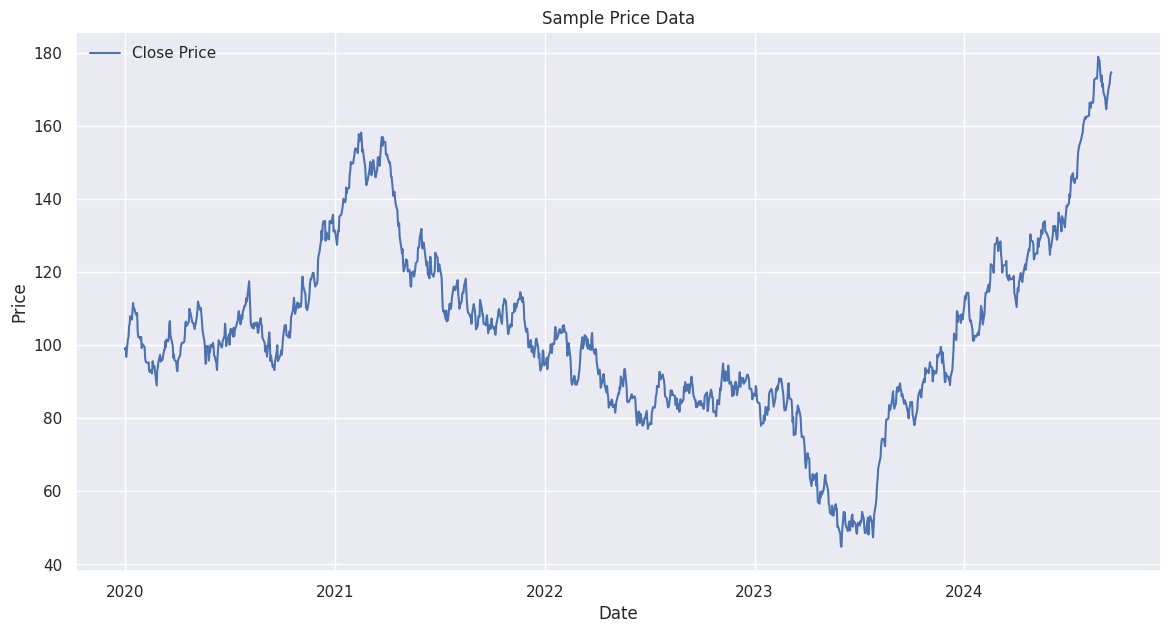

In [11]:
# Visualize the price data
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Close'], label='Close Price')
plt.title('Sample Price Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.show()

In [12]:
# Create two strategies to compare
ma_crossover = MovingAverageCrossover(short_window=50, long_window=200)
rsi_strategy = RSIStrategy(period=14, overbought_threshold=70, oversold_threshold=30)

# Add strategies to the engine
engine.add_strategy(ma_crossover)
engine.add_strategy(rsi_strategy)

Strategy 'MA_Cross_50_200' added to the engine
Strategy 'RSI_14_30_70' added to the engine


In [13]:
# Run backtest for the MA Crossover strategy
ma_results = engine.run_backtest(
    data=data, 
    strategy_name=ma_crossover.name,
    commission_per_trade=0.001,  # 0.1% commission
    slippage_factor=0.0005,      # 0.05% slippage
    capital_per_trade=0.25       # Use 25% of capital per trade
)

# Display the metrics
print("\nMoving Average Crossover Strategy Metrics:")
for key, value in ma_results['metrics'].items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

Backtest completed for strategy 'MA_Cross_50_200'

Moving Average Crossover Strategy Metrics:
start_date: 2020-01-01 00:00:00
end_date: 2024-09-13 00:00:00
trading_days: 1228
total_return_pct: -4.6883
annualized_return_pct: -0.9805
max_drawdown_pct: -18.2989
sharpe_ratio: -0.5018
sortino_ratio: -0.6883
win_rate_pct: 44.4444
total_trades: 18
final_value: 95311.6646


In [14]:
# Run backtest for the RSI strategy
rsi_results = engine.run_backtest(
    data=data, 
    strategy_name=rsi_strategy.name,
    commission_per_trade=0.001,  # 0.1% commission
    slippage_factor=0.0005,      # 0.05% slippage
    capital_per_trade=0.25       # Use 25% of capital per trade
)

# Display the metrics
print("\nRSI Strategy Metrics:")
for key, value in rsi_results['metrics'].items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

Backtest completed for strategy 'RSI_14_30_70'

RSI Strategy Metrics:
start_date: 2020-01-01 00:00:00
end_date: 2024-09-13 00:00:00
trading_days: 1228
total_return_pct: 20.0797
annualized_return_pct: 3.8265
max_drawdown_pct: -25.2509
sharpe_ratio: 0.2547
sortino_ratio: 0.4208
win_rate_pct: 0.0000
total_trades: 1
final_value: 120079.6862


In [15]:
# Compare the strategies
comparison = engine.compare_strategies(data, [ma_crossover.name, rsi_strategy.name])

# Display comparison of key metrics
key_metrics = ['total_return_pct', 'annualized_return_pct', 'max_drawdown_pct', 
               'sharpe_ratio', 'sortino_ratio', 'win_rate_pct', 'total_trades']

print("\nStrategy Comparison:")
comparison.loc[key_metrics]


Strategy Comparison:


,MA_Cross_50_200,RSI_14_30_70
total_return_pct,-4.6883,20.0797
annualized_return_pct,-0.9805,3.8265
max_drawdown_pct,-18.2989,-25.2509
sharpe_ratio,-0.5018,0.2547
sortino_ratio,-0.6883,0.4208
win_rate_pct,44.4444,0.0000
total_trades,18,1


In [3]:
# Fixed visualization functions for portfolio analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Tuple

def plot_equity_curve_fixed(portfolio: pd.DataFrame, metrics: Dict = None, figsize: Tuple = (14, 7)) -> None:
    """
    Plot equity curve with portfolio performance metrics.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, height_ratios=[3, 1])
    
    # Plot equity curve
    ax1.plot(portfolio.index, portfolio['total_value'], color='#00ff88', linewidth=2)
    ax1.set_title('Portfolio Equity Curve', fontsize=16)
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.grid(True, alpha=0.3)
    
    # Add metrics text if provided
    if metrics:
        metrics_text = f"""Total Return: {metrics.get('total_return_pct', 0):.2f}%
Sharpe Ratio: {metrics.get('sharpe_ratio', 0):.2f}
Max Drawdown: {metrics.get('max_drawdown_pct', 0):.2f}%
Win Rate: {metrics.get('win_rate_pct', 0):.1f}%"""
        
        ax1.text(0.02, 0.98, metrics_text, transform=ax1.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    # Plot drawdown
    if 'cum_return' in portfolio.columns:
        cumulative_returns = portfolio['cum_return']
        peak = cumulative_returns.expanding(min_periods=1).max()
        drawdown = (cumulative_returns - peak) / peak * 100
        
        ax2.fill_between(portfolio.index, drawdown, 0, color='red', alpha=0.3)
        ax2.plot(portfolio.index, drawdown, color='red', linewidth=1)
        ax2.set_title('Drawdown (%)', fontsize=14)
        ax2.set_ylabel('Drawdown (%)')
        ax2.set_xlabel('Date')
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_returns_distribution_fixed(portfolio: pd.DataFrame, figsize: Tuple = (14, 7)) -> None:
    """
    Plot returns distribution analysis.
    """
    if 'daily_return' not in portfolio.columns:
        print("Daily returns not found in portfolio data")
        return
    
    returns = portfolio['daily_return'].dropna()
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=figsize)
    
    # Returns distribution histogram
    ax1.hist(returns, bins=50, alpha=0.7, color='#00ff88', edgecolor='black')
    ax1.set_title('Daily Returns Distribution')
    ax1.set_xlabel('Daily Return')
    ax1.set_ylabel('Frequency')
    ax1.grid(True, alpha=0.3)
    
    # Box plot for outliers
    ax2.boxplot(returns, vert=True)
    ax2.set_title('Returns Box Plot')
    ax2.set_ylabel('Daily Return')
    ax2.grid(True, alpha=0.3)
    
    # Rolling volatility
    rolling_vol = returns.rolling(window=30).std() * np.sqrt(252) * 100
    ax3.plot(portfolio.index[30:], rolling_vol[30:], color='orange', linewidth=2)
    ax3.set_title('30-Day Rolling Volatility')
    ax3.set_ylabel('Volatility (%)')
    ax3.grid(True, alpha=0.3)
    
    # Cumulative returns
    cumulative_returns = (1 + returns).cumprod()
    ax4.plot(portfolio.index, cumulative_returns, color='blue', linewidth=2)
    ax4.set_title('Cumulative Returns')
    ax4.set_ylabel('Cumulative Return')
    ax4.set_xlabel('Date')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Visualization functions defined successfully!")

Visualization functions defined successfully!



Plotting MA Crossover strategy results...


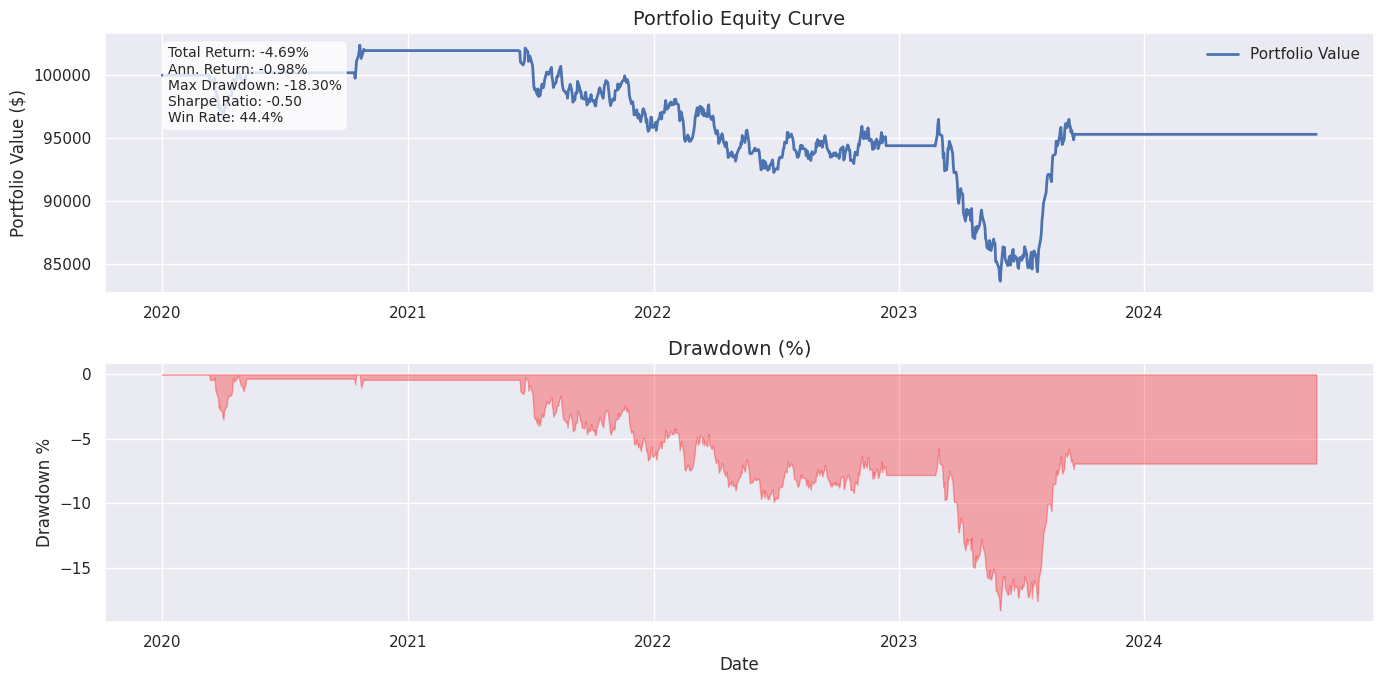

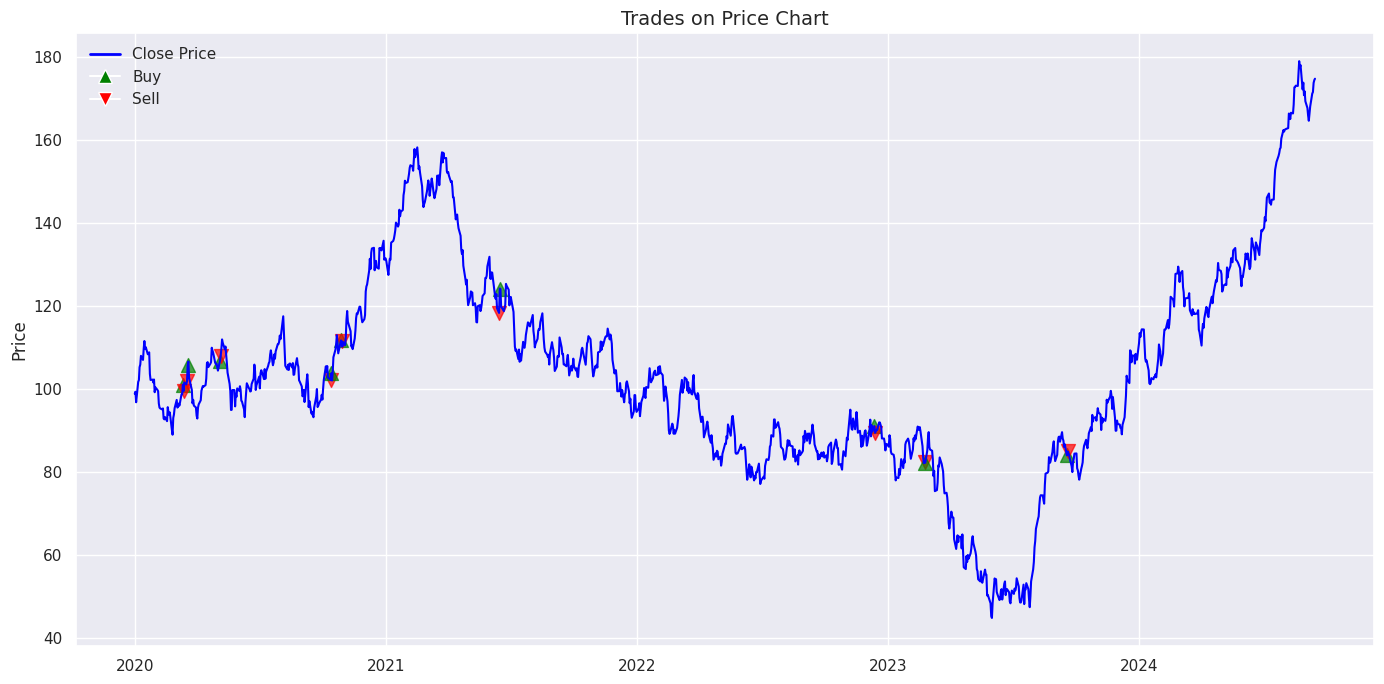

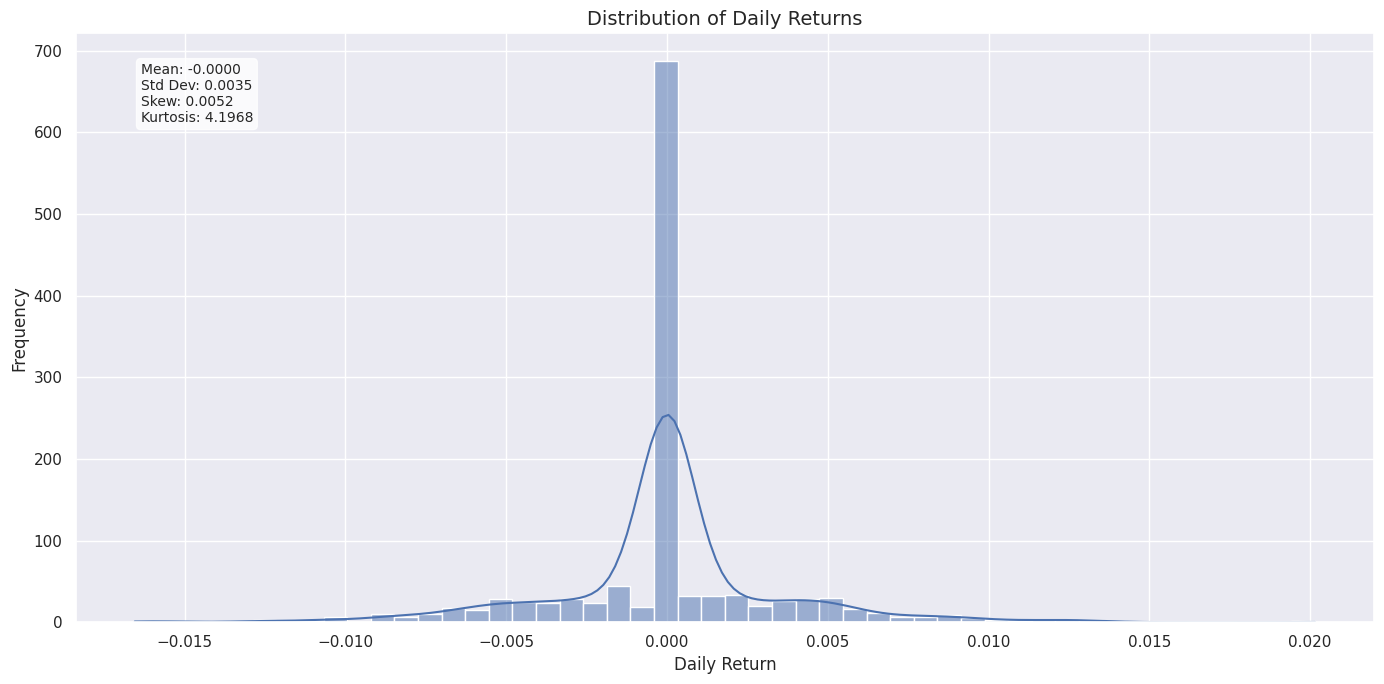

In [ ]:
# Plot MA Crossover strategy results
print("\nPlotting MA Crossover strategy results...")

# Equity curve and drawdown
plot_equity_curve_fixed(ma_results['portfolio'], ma_results['metrics'])

# Visualize trades on the price chart
Reporting.plot_trades(data, ma_results['trades'])

# Distribution of returns
plot_returns_distribution_fixed(ma_results['portfolio'])

In [21]:
# Fix the plotting methods to handle missing columns
def plot_equity_curve_fixed(portfolio: pd.DataFrame, metrics: Dict = None, figsize: Tuple = (14, 7)) -> None:
    """
    Plot the equity curve with optional drawdown overlay.
    
    Args:
        portfolio: Portfolio data with total_value
        metrics: Dictionary of metrics to display
        figsize: Size of the figure
    """
    plt.figure(figsize=figsize)
    
    # Calculate drawdowns if not already present
    if 'drawdown' not in portfolio.columns:
        portfolio_with_drawdown = Metrics.calculate_drawdowns(portfolio.copy())
    else:
        portfolio_with_drawdown = portfolio
    
    # Plot equity curve
    plt.subplot(2, 1, 1)
    plt.plot(portfolio.index, portfolio['total_value'], label='Portfolio Value', linewidth=2)
    plt.grid(True)
    plt.title('Portfolio Equity Curve', fontsize=14)
    plt.ylabel('Portfolio Value ($)')
    plt.legend()
    
    # Add metrics as text if provided
    if metrics:
        textstr = '\n'.join((
            f'Total Return: {metrics["total_return_pct"]:.2f}%',
            f'Ann. Return: {metrics["annualized_return_pct"]:.2f}%',
            f'Max Drawdown: {metrics["max_drawdown_pct"]:.2f}%',
            f'Sharpe Ratio: {metrics["sharpe_ratio"]:.2f}',
            f'Win Rate: {metrics["win_rate_pct"]:.1f}%'
        ))
        
        # Place a text box in upper left
        props = dict(boxstyle='round', facecolor='white', alpha=0.8)
        plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
                      verticalalignment='top', bbox=props)
    
    # Plot drawdown
    plt.subplot(2, 1, 2)
    plt.fill_between(portfolio_with_drawdown.index, portfolio_with_drawdown['drawdown'], 0, color='red', alpha=0.3)
    plt.grid(True)
    plt.title('Drawdown (%)', fontsize=14)
    plt.ylabel('Drawdown %')
    plt.xlabel('Date')
    plt.tight_layout()

def plot_returns_distribution_fixed(portfolio: pd.DataFrame, figsize: Tuple = (14, 7)) -> None:
    """
    Plot the distribution of daily returns.
    
    Args:
        portfolio: Portfolio data with total_value
        figsize: Size of the figure
    """
    # Calculate returns if not already present
    if 'daily_return' not in portfolio.columns:
        portfolio_with_returns = Metrics.calculate_returns(portfolio.copy())
        returns = portfolio_with_returns['daily_return'].dropna()
    else:
        returns = portfolio['daily_return'].dropna()
    
    plt.figure(figsize=figsize)
    
    # Plot returns histogram with kernel density estimate
    sns.histplot(returns, kde=True, bins=50)
    plt.title('Distribution of Daily Returns', fontsize=14)
    plt.xlabel('Daily Return')
    plt.ylabel('Frequency')
    plt.grid(True)
    
    # Add statistics
    mean = returns.mean()
    std = returns.std()
    skew = returns.skew()
    kurt = returns.kurtosis()
    
    textstr = '\n'.join((
        f'Mean: {mean:.4f}',
        f'Std Dev: {std:.4f}',
        f'Skew: {skew:.4f}',
        f'Kurtosis: {kurt:.4f}',
    ))
    
    # Place a text box
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
                  verticalalignment='top', bbox=props)
    
    plt.tight_layout()

print("Fixed plotting functions defined successfully!")

Fixed plotting functions defined successfully!



Plotting RSI strategy results...


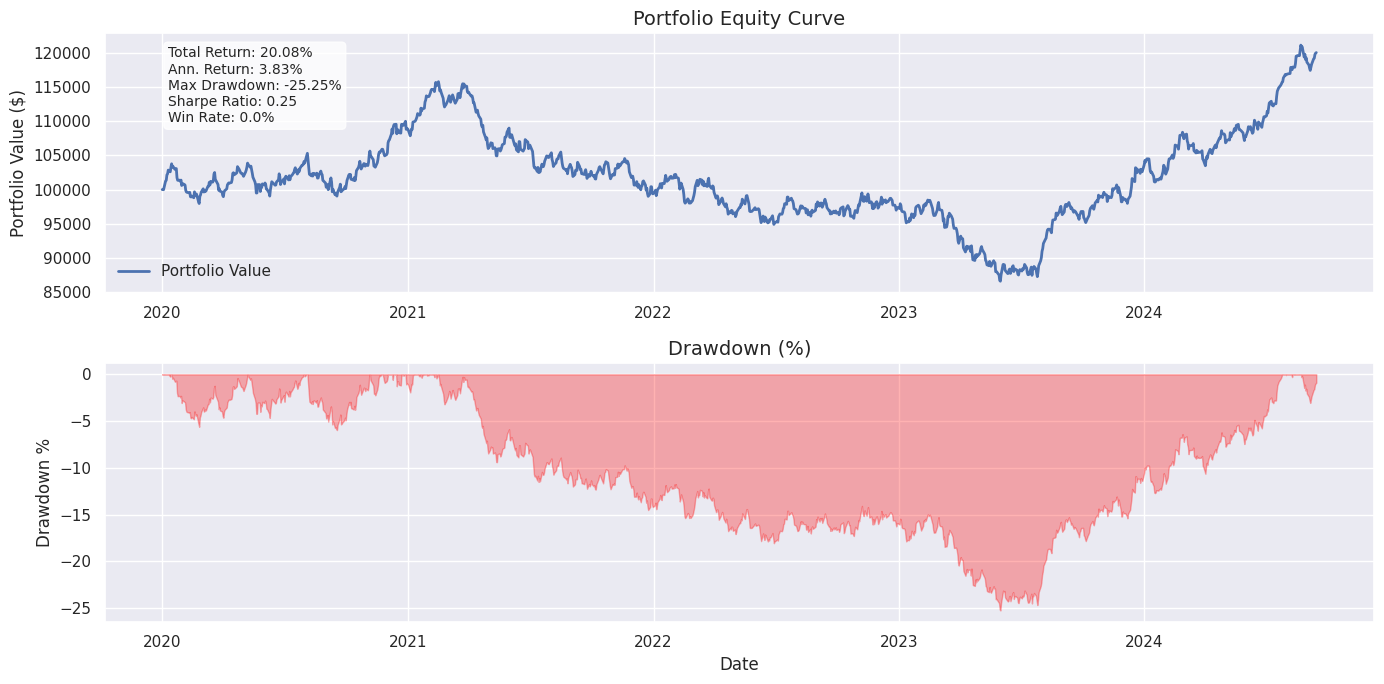

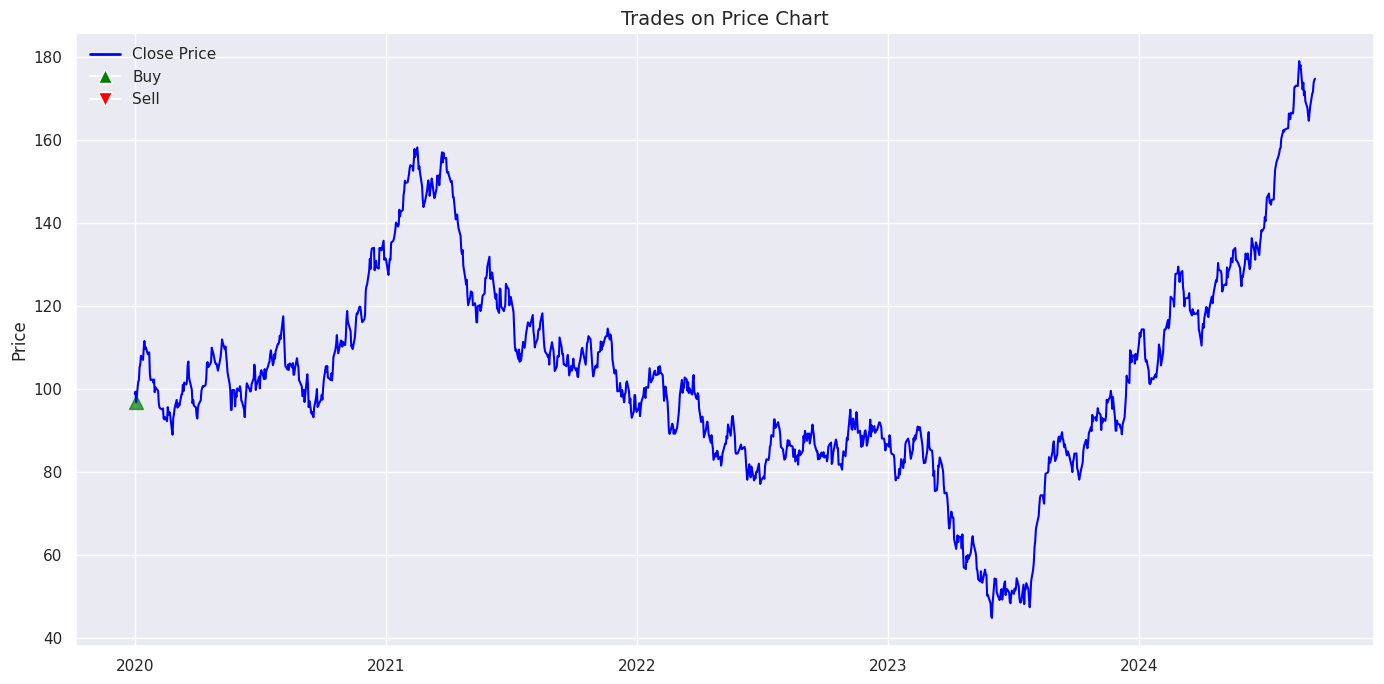

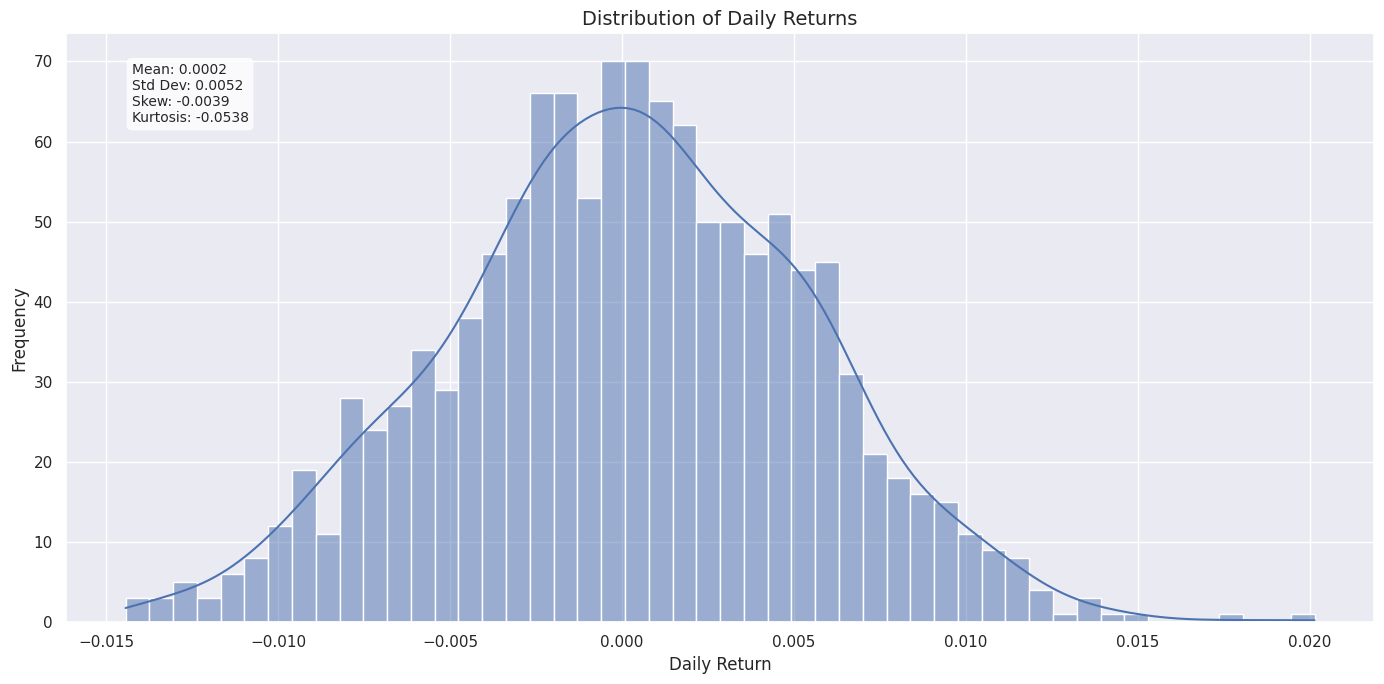

In [24]:
# Plot RSI strategy results
print("\nPlotting RSI strategy results...")

# Equity curve and drawdown
plot_equity_curve_fixed(rsi_results['portfolio'], rsi_results['metrics'])

# Visualize trades on the price chart
Reporting.plot_trades(data, rsi_results['trades'])

# Distribution of returns
plot_returns_distribution_fixed(rsi_results['portfolio'])


Comparing strategies...

Best performing strategy: RSI_14_30_70
Strategy comparison completed successfully!


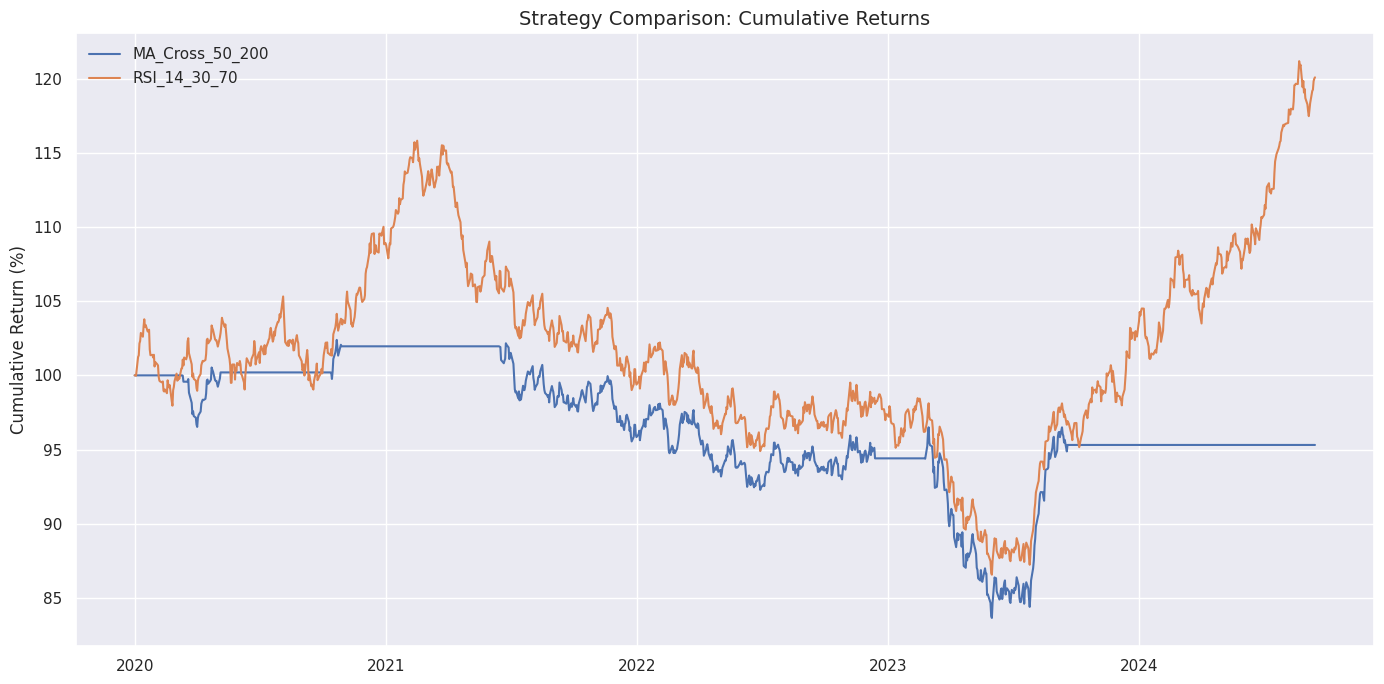

In [26]:
# Compare both strategies
print("\nComparing strategies...")

# Create a fixed strategy comparison function
def plot_strategy_comparison_fixed(portfolio_list: List[pd.DataFrame], figsize: Tuple = (14, 7)) -> None:
    """
    Compare multiple strategies on the same chart.
    
    Args:
        portfolio_list: List of portfolio DataFrames from different strategies
        figsize: Size of the figure
    """
    plt.figure(figsize=figsize)
    
    for portfolio in portfolio_list:
        # Calculate returns if not already present
        if 'cum_return' not in portfolio.columns:
            returns = Metrics.calculate_returns(portfolio)
        else:
            returns = portfolio
        
        # Plot cumulative returns
        plt.plot(returns.index, (1 + returns['cum_return']) * 100, label=portfolio['strategy'].iloc[0])
    
    plt.title('Strategy Comparison: Cumulative Returns', fontsize=14)
    plt.ylabel('Cumulative Return (%)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

# Use the fixed function
portfolios = [ma_results['portfolio'], rsi_results['portfolio']]
plot_strategy_comparison_fixed(portfolios)

# Create interactive dashboard for the best performing strategy
best_strategy = ma_crossover.name if ma_results['metrics']['total_return_pct'] > rsi_results['metrics']['total_return_pct'] else rsi_strategy.name
best_results = ma_results if best_strategy == ma_crossover.name else rsi_results

print(f"\nBest performing strategy: {best_strategy}")
print("Strategy comparison completed successfully!")

## We can see here that RSI based strategy blows MSA out of the water but this is us testing it on synthetic data, but what about actual real data, maybe later on we can pull from yFinance and check

## Conclusion and Next Steps

In this proof of concept, we've built a complete backtesting engine with:

1. **Multi-Source Data Integration** - Ability to load data from CSV, SQL, or generate sample data
2. **Strategy Definition & Execution** - Created flexible strategy framework with two example strategies
3. **Realistic Trading Simulation** - Implemented slippage and commission models
4. **Comprehensive Performance Analysis** - Calculated key metrics like returns, Sharpe ratio, drawdowns
5. **Professional Reporting & Visualization** - Generated static and interactive visualizations
6. **Modular Architecture** - Built with clean, extensible design

### Next Steps:

1. **Add more data sources** - Connect to APIs for real-time and historical data
2. **Implement more strategies** - Add technical indicators and fundamental analysis
3. **Enhance simulation realism** - Add volume-based slippage and market impact models
4. **Portfolio optimization** - Add position sizing and portfolio allocation features
5. **Machine learning integration** - Add ML-based signal generation
6. **Risk management** - Implement stop-loss, take-profit, and risk allocation rules
7. **Performance optimization** - Optimize for speed with larger datasets